In [1]:
import pandas  as pd 
import numpy as np
import matplotlib.pyplot as plt

df  = pd.read_csv('payment_fraud.csv')

### Data cleaning

In [2]:
df.head()

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,Category,isWeekend,label,CustomerName,RegionManager,Region,Salesperson,TransactionAmount,DeviceType,Country,MerchantName,PaymentStatus
0,29,1,17:53:00,Paypal,28,Shopping,Weekday,0,Cust 6583,Eric,East,Eva,3557.69,Mobile,USA,Amazon,Success
1,725,1,17:48:00,Storecredit,0,Electronics,Weekday,0,Cust 2144,Sophie,South,Alice,3532.43,Desktop,USA,Amazon,Success
2,845,1,22:06:00,Crypto,0,Sports,Weekday,0,Cust 5998,Ryan,North,Alice,1889.06,Desktop,UK,Walmart,Success
3,503,1,21:16:00,Crypto,0,Electronics,Weekday,0,Cust 7136,Cameron,Central,Frank,3748.00,Desktop,India,Flipkart,Success
4,2000,1,00:58:00,Crypto,0,Shopping,Weekday,0,Cust 6506,Eric,East,Carlos,2972.85,Desktop,Canada,Amazon,Success


In [3]:
df.describe()

,accountAgeDays,numItems,paymentMethodAgeDays,label,TransactionAmount
count,39126.000000,39126.000000,39126.000000,39126.000000,39126.000000
mean,857.541660,1.084650,122.690768,0.014108,2607.554656
std,804.773225,0.567257,283.670575,0.117939,1444.373255
min,1.000000,1.000000,0.000000,0.000000,100.190000
25%,72.000000,1.000000,0.000000,0.000000,1359.917500
50%,603.000000,1.000000,0.000000,0.000000,2601.265000
75%,1804.000000,1.000000,88.000000,0.000000,3854.402500
max,2000.000000,29.000000,2000.000000,1.000000,5099.860000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39126 entries, 0 to 39125
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accountAgeDays        39126 non-null  int64  
 1   numItems              39126 non-null  int64  
 2   localTime             39126 non-null  str    
 3   paymentMethod         39126 non-null  str    
 4   paymentMethodAgeDays  39126 non-null  int64  
 5   Category              39126 non-null  str    
 6   isWeekend             39126 non-null  str    
 7   label                 39126 non-null  int64  
 8   CustomerName          39126 non-null  str    
 9   RegionManager         39126 non-null  str    
 10  Region                39126 non-null  str    
 11  Salesperson           39126 non-null  str    
 12  TransactionAmount     39126 non-null  float64
 13  DeviceType            39126 non-null  str    
 14  Country               39126 non-null  str    
 15  MerchantName          39126 no

In [5]:
df.isnull().sum()

accountAgeDays          0
numItems                0
localTime               0
paymentMethod           0
paymentMethodAgeDays    0
Category                0
isWeekend               0
label                   0
CustomerName            0
RegionManager           0
Region                  0
Salesperson             0
TransactionAmount       0
DeviceType              0
Country                 0
MerchantName            0
PaymentStatus           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### fraud_detection

In [7]:
total_frauds = df['label'].value_counts()
total_frauds

label
0    38574
1      552
Name: count, dtype: int64

In [11]:
fraud_percentage =  df['label'].value_counts(normalize = True) * 100
round(fraud_percentage , 2)

label
0    98.59
1     1.41
Name: proportion, dtype: float64

In [17]:
fraudby_country = df.groupby('Country')['label'].mean().round(4)*100 
fraudby_country

Country
Canada    1.62
India     1.36
UK        1.29
USA       1.48
Name: label, dtype: float64

In [15]:
fraudby_paymentmethod =( df.groupby('paymentMethod')['label'].mean().round(4).sort_values(ascending=False) * 100)
fraudby_paymentmethod

paymentMethod
CreditCard     1.45
Paypal         1.37
Crypto         1.18
Storecredit    1.10
Name: label, dtype: float64

In [16]:
fraudby_category = (df.groupby('Category')['label'].mean().round(4).sort_values(ascending=False) * 100)

fraudby_weekend = (df.groupby('isWeekend')['label'].mean().round(4).sort_values(ascending=False) * 100)

fraudby_Device = (df.groupby('DeviceType')['label'].mean().round(4) * 100)

fraudby_category  # and fraudby_weekend , fraudby_Device

Category
Shopping       1.49
Electronics    1.37
Food           1.37
Sports         1.18
Name: label, dtype: float64

In [19]:
correlation = (df.corr(numeric_only=True).round(3))
correlation

,accountAgeDays,numItems,paymentMethodAgeDays,label,TransactionAmount
accountAgeDays,1.000,-0.038,0.331,-0.127,0.003
numItems,-0.038,1.000,0.032,0.038,0.011
paymentMethodAgeDays,0.331,0.032,1.000,-0.052,0.009
label,-0.127,0.038,-0.052,1.000,-0.006
TransactionAmount,0.003,0.011,0.009,-0.006,1.000


In [21]:
top_fraud_combination = (
    df.groupby([
        'paymentMethod', 
        'DeviceType',
        'Category'])
['label'].mean().round(4).sort_values(ascending=False).head(10) * 100)

top_fraud_combination

paymentMethod  DeviceType  Category   
Paypal         Mobile      Sports         3.64
Crypto         Desktop     Electronics    3.09
Paypal         Desktop     Shopping       1.99
Storecredit    Mobile      Food           1.97
CreditCard     Mobile      Shopping       1.81
Paypal         Desktop     Sports         1.59
Storecredit    Desktop     Shopping       1.56
CreditCard     Mobile      Electronics    1.54
               Desktop     Food           1.46
               Mobile      Food           1.43
Name: label, dtype: float64

In [22]:
fraud_hotspot_analysis =(
    df.groupby([
        'Region',
        'Country'])
        ['label'].mean().round(4).sort_values(ascending=False).head(10) * 100)
fraud_hotspot_analysis

Region   Country
West     Canada     2.41
East     USA        1.79
Central  UK         1.63
South    Canada     1.59
East     Canada     1.52
West     USA        1.51
Central  India      1.50
West     India      1.48
South    USA        1.44
East     UK         1.44
Name: label, dtype: float64

### Numpy

In [23]:
amounts = df['TransactionAmount'].to_numpy()
account_age = df['accountAgeDays'].to_numpy()
payment_age = df['paymentMethodAgeDays'].to_numpy()
fraud_labels = df['label'].to_numpy()

#Transaction Statistics

print("Average Transaction:", np.mean(amounts))
print("Median Transaction:", np.median(amounts))
print("Maximum Transaction:", np.max(amounts))
print("Minimum Transaction:", np.min(amounts))
print("Standard Deviation:", np.std(amounts))

Average Transaction: 2607.5546557276493
Median Transaction: 2601.2650000000003
Maximum Transaction: 5099.86
Minimum Transaction: 100.19
Standard Deviation: 1444.3547969212646


### charts

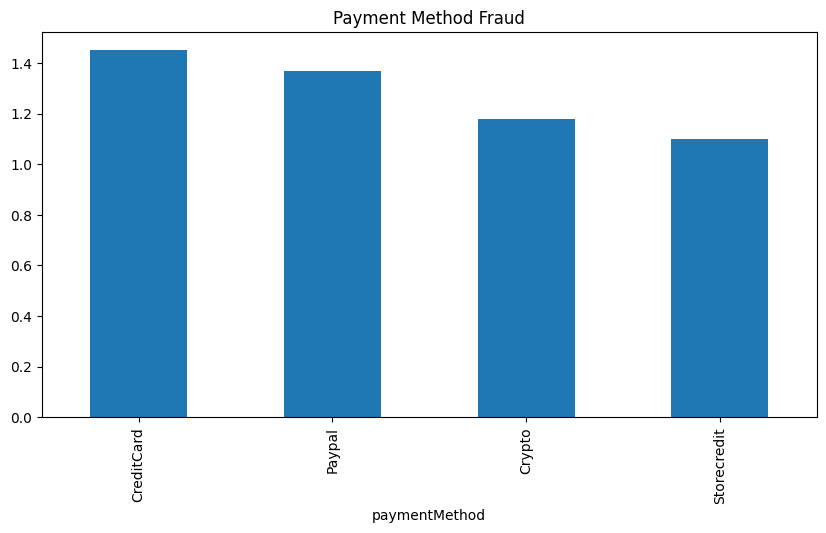

In [28]:
fraudby_paymentmethod.plot(kind='bar' , figsize=(10,5) , title= 'Payment Method Fraud')
plt.show()

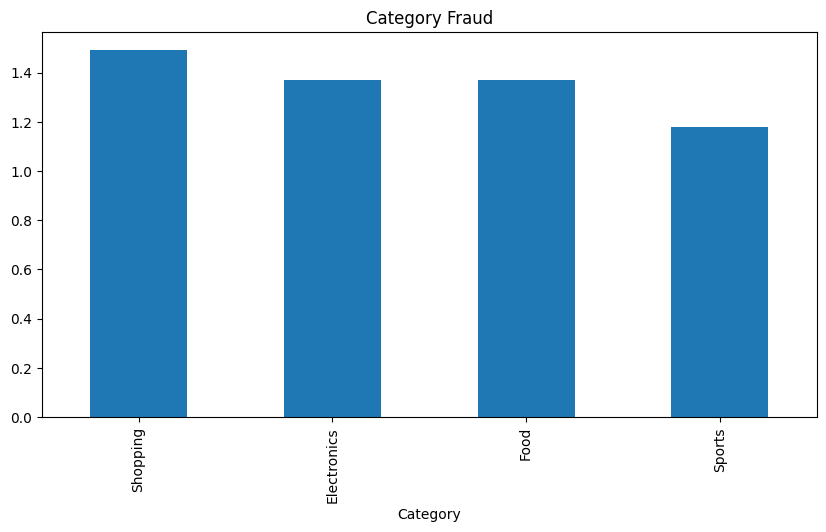

In [29]:
fraudby_category.plot(kind='bar' , figsize=(10,5) , title= 'Category Fraud')
plt.show()

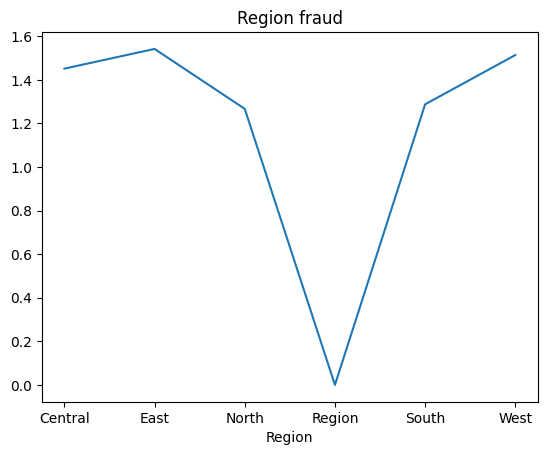

In [31]:
fraudby_region_chart = df.groupby('Region')['label'].mean()*100
fraudby_region_chart.plot(title= "Region fraud")
plt.show()

In [ ]:
# Exporting File : 
df.to_csv("cleaned_fraud_data.csv" , index=False)

### Final buisness insights 

In [36]:

print(
    f"Overall Fraud Rate: {fraud_percentage}%"
)

print(
    f"Highest Risk Payment Method: {fraudby_paymentmethod.idxmax()}"
)

print(
    f"Highest Risk Category: {fraudby_category.idxmax()}"
)

print(
    f"Highest Risk Region: {fraud_hostpot_analysis.idxmax()}")


Overall Fraud Rate: label
0    98.589173
1     1.410827
Name: proportion, dtype: float64%
Highest Risk Payment Method: CreditCard
Highest Risk Category: Shopping
Highest Risk Region: ('West', 'Canada')
